<script src="/course_model/toc.js"></script>

# Advanced Topics in Regression

There are several other important concepts to understand when working with regression models.

**Outcomes**:
- Use logistic regression to predict a binary outcome
- Transform data to make it work with regression
    - Convert numbers stored as text to regular numbers
    - Convert category (usually text) to hot-encoded variables (1 or 0) for each category. Know when to drop the first category.
    - Deal with NaN values by dropping the column, row, or by filling in a value (imputing, e.g. the mean of the column)
    - Bin/Group category data by using replace to combine categories into fewer categories (e.g. combine all zip codes into 5 regions) or with a lookup table.
    - Remove outliers by filtering out rows with values that are outside of a reasonable range (e.g. 3 standard deviations from the mean) or using the clip function to set a maximum value for the column.
    - Remove old columns after checking to make sure that the new column works as expected.
- Describe the overall process of building a model
    - Check data for potential issues and to understand how data is being stored (esp at what level of granularity)
    - Clean the data and create new features. However, don't get too carried away with feature engineering. You can always come back and add more features later if you need to.
    - Examine correlations to get a sense of which features are likely to be important and to check for multicolinearity.
    - Build the model and check the results.
    - Repeat!
- Detect common pitfalls of regression
    - Describe the impaact of an outlier on a regression model, and how to detect and address outliers.
    - Describe the impact of a non-linear relationship between the independent and dependent variable, and how to detect and address non-linearity.
    - Describe the impact of multicolinearity on a regression model, and how to detect and address multicolinearity.
- Interpret regression results
    - Describe the meaning of R^2 and adjusted R^2, and how to use them to evaluate the fit of a regression model.
    - Describe the meaning of the coefficients for each independent variable, and how to interpret them in the context of the data.
    - Describe the meaning of p-values for each independent variable, and how to use them to determine which independent variables are significantly associated with the dependent variable.

**Links**:
- [logistic template](logistic_template.ipynb)
- [Ames Regression](ames_template.ipynb) and [data](ames_lite.csv)
- [Helpful tutorial on Logistic Regression](https://mlu-explain.github.io/logistic-regression/)


## Topic 1: Logistic regression

Logistic regression is used when the dependent variable is a categorical represented by 0 or 1. It estimates the probability that a given input point belongs to a certain class.

Key Concepts:
- The line drawn by logistic regression is an S-shaped curve (sigmoid function) that maps any real-valued number into the (0, 1) interval. This is different from linear regression, which draws a straight line.
- The major advantage of logistic regression is that it draw a steeper curve between classes, which can better capture the relationship when the outcome is either a zero or a one.
- The major downside of logistic regression is that it is less interpretable than linear regression. The coefficients represent the change in the log-odds of the outcome for a one-unit change in the predictor variable, which can be less intuitive than the coefficients in linear regression.

Interpretation:
- Logistic regression is is similar to linear regression, but with some key differences
- Overall model
    - Instead of adjusted R^2, we use Pseudo R^2 (e.g., McFadden's R^2) to assess model fit.
- Individual predictors
    - A coefficient in logistic regression indicates the change in the log-odds of the outcome for a one-unit increase in the predictor variable, holding all other variables constant.
    - To convert log-odds to odds, use the exponential function: odds = exp(coefficient).
    - To convert odds to probability, use the formula: probability = odds / (1 + odds).

When used in a classical statistics context, logistic regression typically does not involve train/test splits or cross-validation. Instead, the focus is on interpreting coefficients and assessing model fit using statistical tests and metrics specific to logistic regression.

In [6]:
# Check field types and values
import pandas as pd
import numpy as np

# Sales table
df_logistic = pd.DataFrame({
    'office_size': [1, 3, 1, 6, 8, 9, 2, 4, 3, 2],
    'closed': [True, False, True, False, False, False, True, True, False, True],
})

# Fix columns
df_logistic = df_logistic.assign(closed = df_logistic['closed'].astype(int))  # Convert boolean to int (1/0)


df_logistic

,office_size,closed
0,1,1
1,3,0
2,1,1
3,6,0
4,8,0
5,9,0
6,2,1
7,4,1
8,3,0
9,2,1


                            OLS Regression Results                            
Dep. Variable:                 closed   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     7.848
Date:                Tue, 06 Jan 2026   Prob (F-statistic):             0.0231
Time:                        11:53:33   Log-Likelihood:                -3.8400
No. Observations:                  10   AIC:                             11.68
Df Residuals:                       8   BIC:                             12.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.0082      0.221      4.569      

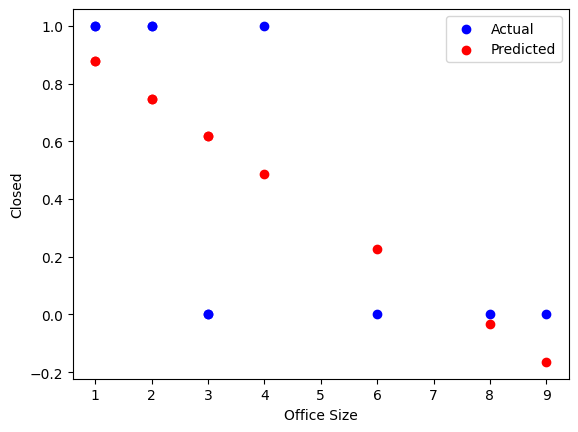

In [7]:
# OLS regression example with statsmodels
import statsmodels.api as sm

# Prepare the data
X = df_logistic[['office_size']]
y = df_logistic['closed']

# Fit the model using OLS for comparison
X = sm.add_constant(X)  # Adds a constant term to the predictor
model_ols = sm.OLS(y, X).fit()
predictions = model_ols.predict(X)
print(model_ols.summary())

# Print a chart comparing actual vs predicted
import matplotlib.pyplot as plt
plt.scatter(df_logistic['office_size'], y, label='Actual', color='blue')
plt.scatter(df_logistic['office_size'], predictions, label='Predicted', color='red')
plt.xlabel('Office Size')
plt.ylabel('Closed')
plt.legend()
plt.show()



Optimization terminated successfully.
         Current function value: 0.352287
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 closed   No. Observations:                   10
Model:                          Logit   Df Residuals:                        8
Method:                           MLE   Df Model:                            1
Date:                Tue, 06 Jan 2026   Pseudo R-squ.:                  0.4918
Time:                        11:53:33   Log-Likelihood:                -3.5229
converged:                       True   LL-Null:                       -6.9315
Covariance Type:            nonrobust   LLR p-value:                  0.009028
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.9810      2.645      1.505      0.132      -1.203       9.165
office_size    -1.2246    

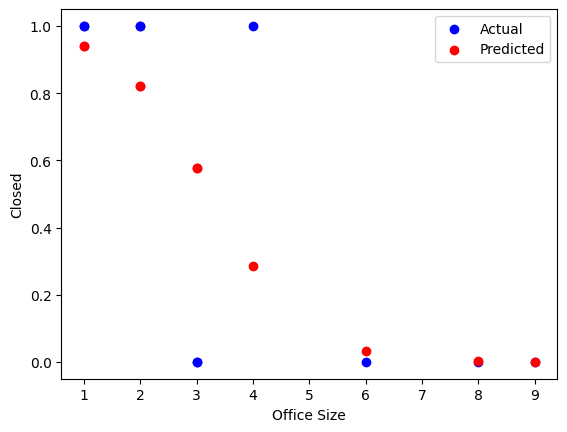

In [8]:
# Logistic regression example with statsmodels
import statsmodels.api as sm

# Prepare the data
X = df_logistic[['office_size']]
y = df_logistic['closed']
X = sm.add_constant(X)  # Adds a constant term to the predictor

# Fit the logistic regression model
model_logistic = sm.Logit(y, X)
result = model_logistic.fit()
# Display the summary of the model
print(result.summary())

predictions = result.predict(X)

# Print a chart comparing actual vs predicted
import matplotlib.pyplot as plt
plt.scatter(df_logistic['office_size'], y, label='Actual', color='blue')
plt.scatter(df_logistic['office_size'], predictions, label='Predicted', color='red')
plt.xlabel('Office Size')
plt.ylabel('Closed')
plt.legend()
plt.show()



## Topic 2: Data transformations

### Handle missing values

We often want to exclude rows with missing values. We can do this with the `dropna` function.
However, this can sometimes remove too much data, so be careful! 

`df = df.dropna(subset=['column1', 'column2'])`


### Fix missing values

We sometimes will want to fill in missing values. We can do this with the `fillna` function.

`df = df.assign(column = df['column'].fillna(value))`


Or, we may want to change one or two specific column values. We can do this with the `replace` function.

`df = df.assign(column = df['column'].replace({old_value: new_value}))`


If you have a specific value you want to replace, you can also use the `np.where` function.

`df = df.assign(column = np.where(df['column'] == old_value, new_value, df['column']))`


### Convert text to numbers

We can use the `astype` function to convert text to numbers. This is useful for when a column is stored as text but contains numeric values.
Note that you will need to remove any non-numeric characters first, such as commas or dollar signs.

`df = df.assign(column = df['column'].str.replace('$', '').astype(float))`

### Collapse categories and create new columns

We can collapse categories by using the `replace` function. This is useful for categorical variables with many levels.

`data['column'] = data['column'].replace({'old_value': 'new_value'})`


### Create new columns with 1/0 variables

We can create new columns with 1/0 variables using the `np.where` function.

`data['new_column'] = np.where(data['column'] == 'value', 1, 0)`

### Remove or cap outliers

Outlier values can throw off our model. We can remove them by using the `np.where` function, or we can cap them by using the `clip` function.

`df = df.assign(column = df['column'].clip(lower=lower_limit, upper=upper_limit))`

### Remove old columns

We can remove old columns by using the `drop` function.

`df = df.drop(columns=['old_column1', 'old_column2'])`


In [ ]:
# Sample code
import pandas as pd
import numpy as np

# Sales table
df_raw = pd.DataFrame({
    'sales_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'sales_as_text': ['1,000', '2,000', '2,500', '10,000', '1,900', np.nan, '3,000', '4,000', '5,000', '6,000'],
    'profit': [0, 400, 1600, 6250, 240, np.nan, 900, 1600, 500, 600],
    'office_size': [16, 1, 2, 3, 1, 3, 2, 4, 5, 2],
    'closed': [True, False, True, False, False, False, True, True, False, True],
    'state': ['ca', 'ca', np.nan, 'NY', 'ca', np.nan, 'NY', 'NY', 'ca', 'ca'],
})


# Create a copy of the raw data to clean
df = df_raw.copy()

# Drop bad rows with missing profit
df = df.dropna(subset=[ 'profit'])

# Change NY to ny
df = df.assign(
    state = df['state'].str.lower()
)

# Convert sales_as_text to numeric (remove commas and convert to float)
df = df.assign(
    sales_as_number = df['sales_as_text'].str.replace(',', '').astype(float)
)

# Create as is_ny column
df = df.assign(
    is_ny = np.where(df['state'] == 'ny', 1, 0)
)

# Fill empty states with ny
df = df.assign(
    state = df['state'].fillna('ny')
)

# Cap the number of office_size field to avoid outliers
df = df.assign(
    office_size_clipped = df['office_size'].clip(upper=10)
)

# Remove columns that we do not need for our model
df = df.drop(columns=['sales_as_text', 'sales_id', 'closed'])

df

,profit,office_size,state,sales_as_number,is_ny,office_size_clipped
0,0.0,16,ca,1000.0,0,10
1,400.0,1,ca,2000.0,0,1
2,1600.0,2,ny,2500.0,0,2
3,6250.0,3,ny,10000.0,1,3
4,240.0,1,ca,1900.0,0,1
6,900.0,2,ny,3000.0,1,2
7,1600.0,4,ny,4000.0,1,4
8,500.0,5,ca,5000.0,0,5
9,600.0,2,ca,6000.0,0,2


## Topic 3

Interpretation tips:

- Follow the overall process:
    1. Check field types and values
    1. Clean the data and create new features
    1. Examine the relationship between the independent and dependent variables with a scatterplot or correlation matrix
    1. Fit the model and interpret the results
    1. Repeat 
- Start with a simple model, using just 1 independent and 1 dependent variable. This will help you understand the relationship between the two variables and how to interpret the coefficients. Then, go back and add another independent variable, and so on. This will help you understand how the coefficients change as you add more variables to the model.

Dealing with NaN values:

The best way to deal with NaN values depends on the context and the amount of missing data. 
- If you have a lot of missing data, it may be best to drop the column. For example, if you're missing 50% of the values in a column, it may be best to drop the column.
- For a rare occurance, you may want to drop the row. However, be careful when dropping rows, as this can introduce bias into your model if the missing values are not random. It may also result in droping a lot of rows, so count to see how much data you are throwing out. 
- If you can logically assume a value, imputation may be the best approach. However, this requires a logical reason for why the value is missing and what the value should be. For example, if you have a column for "number of children" and you have a missing value, you might assume that the missing value is 0 (i.e. the person has no children). However, if you have a column for "income" and you have a missing value, it may be more difficult to impute a reasonable value.

Common problems:

- Make sure that data types are clean! If you have a column that is supposed to be numeric but is stored as text, this can cause problems with the model. You can use the `astype` function to convert the column to the correct data type.
- Understand relationship between variables.
    - If the relationship between the independent and dependent variable is not linear, then a linear regression model may not be appropriate. In this case, you may want to consider using a different type of model, such as a polynomial regression or a non-parametric model.
    - If the relationship between the independent and dependent variable is not linear, you can try transforming the data to make it more linear. For example, you can take the logarithm of the independent variable.
- Check for outliers and influential points. Outliers can have a large impact on the coefficients and the overall model fit. You can use scatterplots or leverage plots to identify outliers and influential points. If you find any, you can try removing them or using a different type of model that is less sensitive to outliers.

Model Evaluation:

- R^2 ranges from 0 to 1, with higher values indicating a better fit. However, R^2 can be misleading when comparing models with different numbers of independent variables, as it will always increase as you add more variables. Adjusted R^2 accounts for the number of independent variables in the model and can be used to compare models with different numbers of independent variables.
    - R^2 over 0.9 may indicate a problem
    - R^2 over 0.7 or higher are very good
    - R^2 over 0.4 is moderate
    - R^2 over 0.2 is low
    - R^2 under 0.2 would not generally be acceptable.
    - However, these values vary a lot depending on the context and the field of study.
- Having a very high R^2 may indicate multicolinearity. This means that you are including multiple independent variables that are highly correlated with each other, which can make it difficult to interpret the coefficients and can lead to overfitting. You can check for multicolinearity by looking at the correlation matrix.
- Look at the coefficient for each independent variable and its p-value. A significant p-value (typically less than 0.05) indicates that the independent variable is significantly associated with the dependent variable, while a non-significant p-value indicates that there is no evidence of an association between the independent variable and the dependent variable.
    - However p-values can be misleading, as they are also based on the sample size. A true relationship may be non-significant if the sample size is too small. If you have a very large dataset, you may find that even very small effects are statistically significant. In this case, it is important to also look at the size of the coefficient and the confidence interval to determine if the effect is meaningful.